## What we're gonna do?

After a long day of studying, I found myself sitting by the window, breathing in the air and thinking about football, when I smelled cigarette smoke and noticed my neighbor was smoking. Then a question appeared in my mind: "How badly the habit of smoke affect our medical spences?"

unfortunatelly, I don't work for a hospital nor a drugstore, but I've internet on my house and could simply search for a data base of smokers and non smorkes realted with BMI (body mass index), medical charges, number of children a people have and other statistics.

And yes, we're gonna make a really good Data Analyse to discover if THERE IS or NOT a correlation between smoking and high medical charges. Plus, at the and of our study we'll build a Supervisioned Learning Machine and a Linear Regression to predict if a random person inside our dataset is a smoker or not.

If that sounds good for you, let's get this up!

In [1]:
import numpy as np
import sklearn as skl
import pandas as pd  # Strongly recomend to use pandas 2.2.2, cuz he's compatible with good data wrengler functions! Download Datawrengler
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Downloading all data and creating a data frame

In [2]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

df = pd.read_csv(url)
df.to_csv('medical.csv')
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Lets print all kind of data on each column for understandment of what we're dealing

In [4]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print(80*'=')

age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex
['female' 'male']
bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765 34

Searching for null data

In [5]:
df.isnull().sum()

# Fortunately there's no null data, which means data collector were amazing at this project

# OBS: Remenber, that's not the standart so we must do this in EVERY project to avoid big problems later

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

# Studing age dsitribuction

In [7]:
print(7*'=','MEAN AGE',7*'=')
print(df['age'].mean())
print(6*'=','MEDIAN AGE',6*'=')
print(df['age'].median())
print(7*'=','MODE AGE',7*'=')
print(df['age'].mode())

======= MEAN AGE =======
39.20702541106129
====== MEDIAN AGE ======
39.0
======= MODE AGE =======
0    18
Name: age, dtype: int64


# Taking percentage of each age by its counts

In [8]:
age_counts = df.age.value_counts()
age_percentage = df.age.value_counts(normalize=True)*100

df_distribution_age = pd.DataFrame({
    'Contagem': age_counts,
    'Porcentagem (%)': age_percentage
})
df_distribution_age.head(5) # Top 5 biggest distribuctions

,Contagem,Porcentagem (%)
age,,
18,69,5.156951
19,68,5.082212
46,29,2.167414
52,29,2.167414
50,29,2.167414


As we can see, Mean and Median values are pretty close at point we can say theres two options:

1) The distribuction is gonna be a constant height of continuous columns

2) The distribuction is gonna be a normal function which the meadian point is the same as mean on graph

* To test this, we're plotting a age counting distribuction to see how it looks!

In [9]:
# By sturges's formulas to determine number of bins (age gap per column in this case)
k = int(1 + 3.322*np.log10(len(df)))
k
# This value 'k' is gonna be used in all graphs, remember him

11

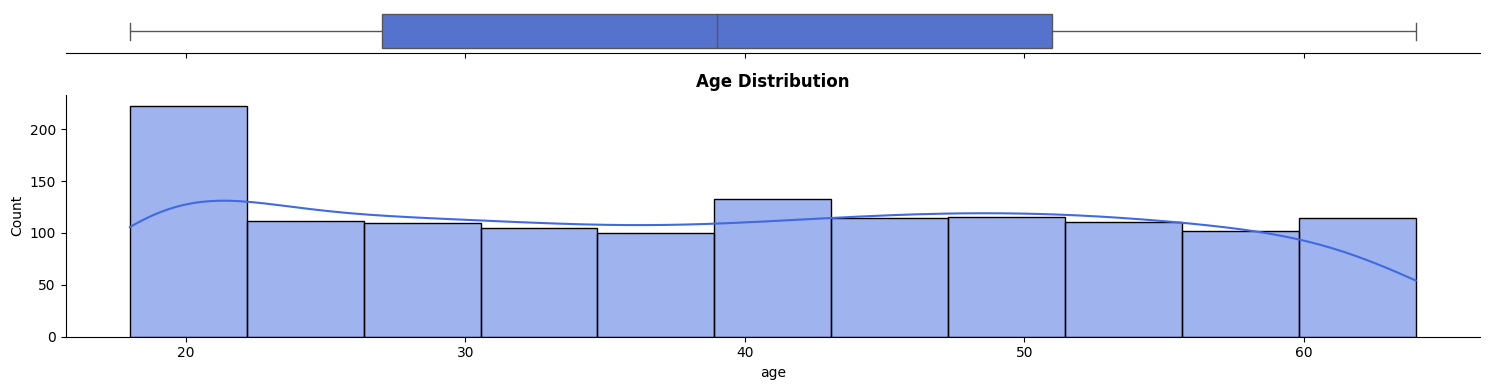

In [10]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(15, 4), sharex=True, 
                                     gridspec_kw={"height_ratios": (.15, .85)})

# 1. Boxplot superior axis
sns.boxplot(data=df, x="age", ax=ax_box, color="royalblue")
ax_box.set(xlabel='') # Remove label x so we don't have a duplicate label on x-axis

# 2. Histogram below axis
sns.histplot(data=df, x="age", color='royalblue', bins=k, kde=True, ax=ax_hist)
ax_hist.set_title('Age Distribution', fontsize=12, fontweight='bold')

# Aesthetic
sns.despine(ax=ax_hist) # Remove bordas desnecessárias
sns.despine(ax=ax_box, left=True) # Remove bordas do boxplot
ax_box.set_yticks([]) # Remove escala lateral do boxplot

plt.tight_layout()
plt.show()

# Studying bmi distribuction 

In [11]:
print(7*'=','MEAN BMI',7*'=')
print(df['bmi'].mean())
print(6*'=','MEDIAN BMI',6*'=')
print(df['bmi'].median())
print(7*'=','MODE BMI',7*'=')
print(df['bmi'].mode())

======= MEAN BMI =======
30.66339686098655
====== MEDIAN BMI ======
30.4
======= MODE BMI =======
0    32.3
Name: bmi, dtype: float64


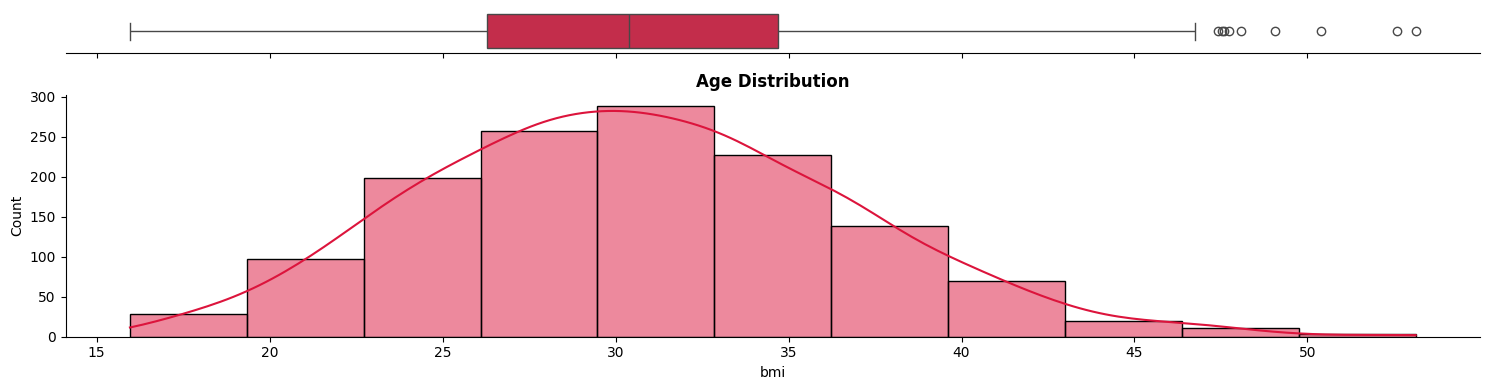

In [12]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(15, 4), sharex=True, 
                                     gridspec_kw={"height_ratios": (.15, .85)})

# 1. Boxplot superior axis
sns.boxplot(data=df, x="bmi", ax=ax_box, color="crimson")
ax_box.set(xlabel='') # Remove label x so we don't have a duplicate label on x-axis

# 2. Histogram below axis
sns.histplot(data=df, x="bmi", color='crimson', bins=k, kde=True, ax=ax_hist)
ax_hist.set_title('Age Distribution', fontsize=12, fontweight='bold')

# Aesthetic
sns.despine(ax=ax_hist) # Remove bordas desnecessárias
sns.despine(ax=ax_box, left=True) # Remove bordas do boxplot
ax_box.set_yticks([]) # Remove escala lateral do boxplot

plt.tight_layout()
plt.show()

At this time, we see that's a normal distribuction

Observe that there's some 'points' that escapes of box marginal concept of Upper Maginal, it means that we've some exceptions to bmi distribuction. In other words: People with big problems with their body health really above what should be a normal bmi.

Even though plotly graph is interactive, and in certain way it gives us our answer, we can find our parameters in a better route!

In [13]:
df.bmi.describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [14]:
# We must obtain q1 and q3 by our own to find upper and lower marginal

q1 = df.bmi.quantile(0.25)
q3 = df.bmi.quantile(0.75)

print(f'The value of 25% first elements Q1: {q1:.2f} e 75% first elements Q3: {q3:.2f}')

# Calculating the Interquartile Range
iqr = q3 - q1

# Find marginals
lower_marginal = q1 - (1.5 * iqr)
upper_marginal = q3 + (1.5 * iqr)

print(f'The lower marginal is {lower_marginal:.2f} and the upper marginal is {upper_marginal:.2f}')

The value of 25% first elements Q1: 26.30 e 75% first elements Q3: 34.69
The lower marginal is 13.70 and the upper marginal is 47.29


Now, we can caltulate people which is outliers lower and upper. Also, we'll discover people who is below and above the ideal range of bmi

In [15]:
people_bmi_above = len(df[df['bmi']>upper_marginal])
people_bmi_bellow = len(df[df['bmi']<lower_marginal])

print(f'People with bmi above upper marginal: {people_bmi_above}')
print(f'People with bmi bellow lower marginal: {people_bmi_bellow}')

People with bmi above upper marginal: 9
People with bmi bellow lower marginal: 0


Let's see now the values that outliers above upper marginal in BMI

In [16]:
print(27*'=')
print(f'Upper Marginal: {upper_marginal:.2f}')
print(27*'=')
for value in df[df['bmi']>upper_marginal]['bmi']:
    print(value)

Upper Marginal: 47.29
49.06
48.07
47.52
47.41
50.38
47.6
52.58
47.74
53.13


# Avoid outliers its sugested for Data Science, so our work can be free of exceptions on data

In [17]:
df.shape # BEFORE

(1338, 7)

In [18]:
df = df[df['bmi'] < 47.3]
df.shape # AFTER REMOVING OUTLIERS

(1329, 7)

### Plotting Charges x BMI without outliers

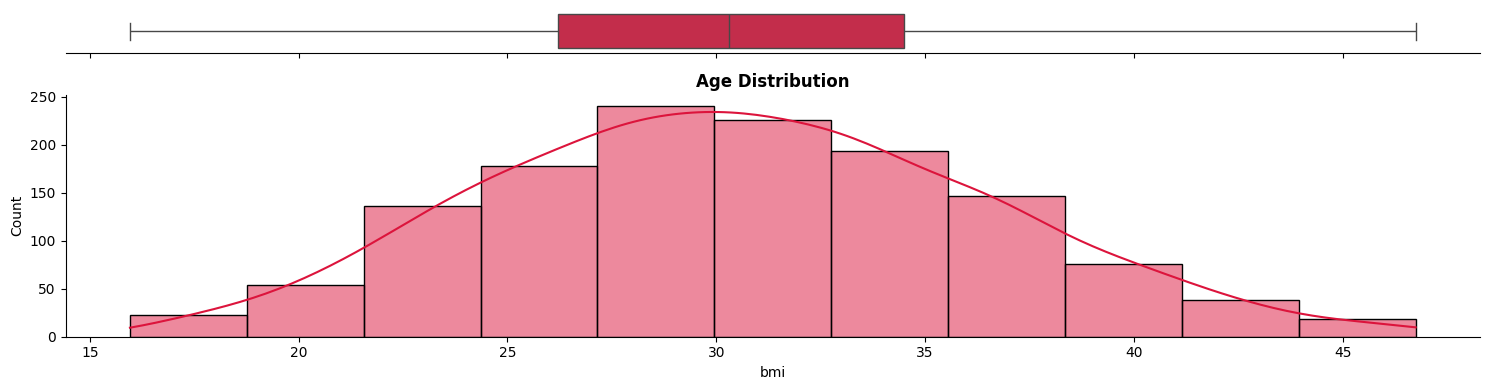

In [19]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(15, 4), sharex=True, 
                                     gridspec_kw={"height_ratios": (.15, .85)})

# 1. Boxplot superior axis
sns.boxplot(data=df, x="bmi", ax=ax_box, color="crimson")
ax_box.set(xlabel='') # Remove label x so we don't have a duplicate label on x-axis

# 2. Histogram below axis
sns.histplot(data=df, x="bmi", color='crimson', bins=k, kde=True, ax=ax_hist)
ax_hist.set_title('Age Distribution', fontsize=12, fontweight='bold')

# Aesthetic
sns.despine(ax=ax_hist) # Remove bordas desnecessárias
sns.despine(ax=ax_box, left=True) # Remove bordas do boxplot
ax_box.set_yticks([]) # Remove escala lateral do boxplot

plt.tight_layout()
plt.show()

The measurements of body mass index seem to form a [Gaussian distribution](https://en.wikipedia.org/wiki/Normal_distribution) centered around the value 30, with a few outliers towards the right. Here's how BMI values can be interpreted ([source](https://study.com/academy/lesson/what-is-bmi-definition-formula-calculation.html)):

![](https://i.imgur.com/lh23OiY.jpg)

> **EXERCISE**: Can you explain why the distribution of ages forms a uniform distribution while the distribution of BMIs forms a gaussian distribution?
>
> ???

Answer: 

The distribution of BMIs is Gaussian because biological traits influenced by multiple independent factors (genetic and environmental) naturally tend toward a Normal Distribution. A peak at 30 indicates that this is the mean/median of the population, where most individuals are clustered.
On the other hand, the Uniform distribution of ages suggests a controlled sampling process. Instead of representing a natural population pyramid, the researchers likely selected an equal number of participants for each age bracket to ensure balanced representation across the study.

# Are there a relation between smoking with the ohter columns

In [20]:
# How many people smoke and what the percentage?
df_smokers = df[df['smoker']=='yes']
df_non_smokers = df[df['smoker']=='no']
num_smokers = len(df_smokers)

print(f'The number of smoker is {num_smokers} and non-smokers is {len(df_non_smokers)}')
print(f'Percentual of smokers on data: {(num_smokers *100/len(df)):.2f}%')

The number of smoker is 271 and non-smokers is 1058
Percentual of smokers on data: 20.39%


Age of people who smokes

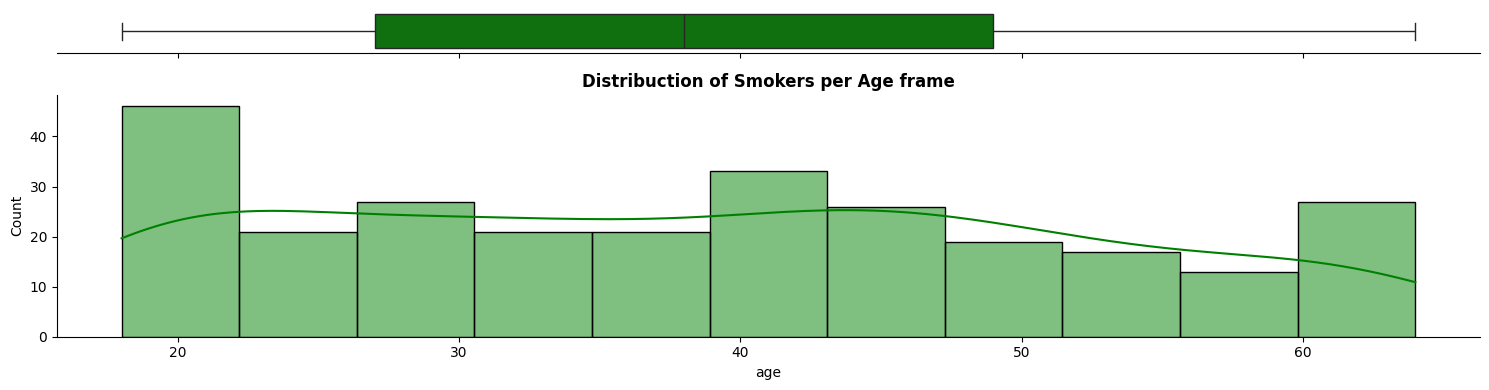

In [21]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(15, 4), sharex=True, 
                                     gridspec_kw={"height_ratios": (.15, .85)})

# 1. Boxplot superior axis
sns.boxplot(data=df_smokers, x="age", ax=ax_box, color="green")
ax_box.set(xlabel='') # Remove label x so we don't have a duplicate label on x-axis

# 2. Histogram below axis
sns.histplot(data=df_smokers, x="age", color='green', bins=k, kde=True, ax=ax_hist)
ax_hist.set_title('Distribuction of Smokers per Age frame', fontsize=12, fontweight='bold')

# Aesthetic
sns.despine(ax=ax_hist) # Remove bordas desnecessárias
sns.despine(ax=ax_box, left=True) # Remove bordas do boxplot
ax_box.set_yticks([]) # Remove escala lateral do boxplot

plt.tight_layout()
plt.show()

We see that based on data, there's two conclusions:

1) Sample was select to distribute smokers uniformily intetionally

2) There's no realtion between age and smoking

### Men x Women - Smokers

In [22]:
men_smmokers = df_smokers[df_smokers['sex']=='male']
women_smmokers = df_smokers[df_smokers['sex']=='female']

print(f'Number of smokers')
print(f'Men: {len(men_smmokers)}')
print(f'Women: {len(women_smmokers)}')
print(35*'=')
print(f'Percentage of Men and Women smokers')
print(f'Men: {len(men_smmokers)*100/len((df_non_smokers[df_non_smokers['sex']=='male'])):.2f}%')
print(f'Men: {len(women_smmokers)*100/len((df_non_smokers[df_non_smokers['sex']=='female'])):.2f}%')

Number of smokers
Men: 158
Women: 113
Percentage of Men and Women smokers
Men: 30.86%
Men: 20.70%


## But what about smoking and Medical Charges?

To correctly analyse this, we must compare smokers and non-smokers

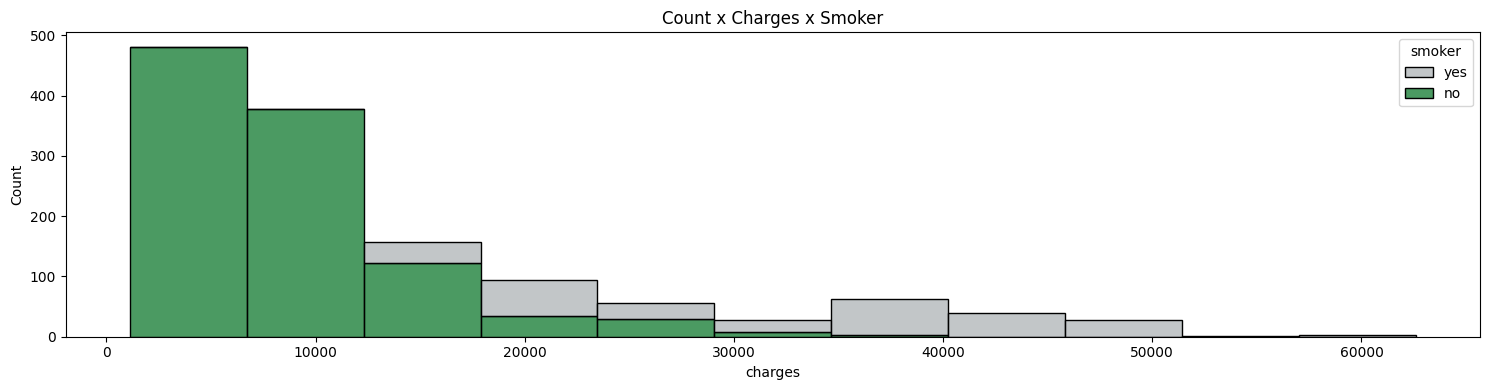

In [23]:
fig = plt.subplots(figsize=(15, 4), sharex=True)

# palette
palette = sns.color_palette(["#aeb3b6", "#0f782e"])

ax = sns.histplot(data=df, x="charges", palette=palette, hue='smoker', multiple='stack', bins=k)
ax.set_title('Count x Charges x Smoker')

# Aesthetic
plt.tight_layout()
plt.show()

First, we can easily see that as the charges grown, the count of smokers grown as well. Which points us to a strong relation between these two.

And we can associate that as: "As it seems, smoking probably is bad for health, so people who smokes have more chances to spent more money with medicine and at the hospital"

In [24]:
print('Smokers Medical Charges described')
print(40*'=')
print(df_smokers['charges'].describe())
print(40*'=')
print(20*'//')
print(40*'=')
print('Non Smokers Medical Charges described')
print(40*'=')
print(df_non_smokers['charges'].describe())



Smokers Medical Charges described
count      271.000000
mean     31835.343855
std      11384.541798
min      12829.455100
25%      20759.808425
50%      34303.167200
75%      40936.857450
max      62592.873090
Name: charges, dtype: float64
////////////////////////////////////////
Non Smokers Medical Charges described
count     1058.000000
mean      8442.167174
std       6002.861451
min       1121.873900
25%       3988.404750
50%       7341.416000
75%      11363.151150
max      36910.608030
Name: charges, dtype: float64


### There's a lot information in here:

1) Even though are less smokers (274) than non-smokers (1064), smokers in mean spend almost 4x than non-smokers!

2) The minor charge of smokers ($1282.45) is bigger than 75% of non-smoker charges (11362.88) and approximately 50% of smokes's spends are bigger than max charge of non-smokers ($36910.60)

3) The Standart Deviation of smokers ($11541.55) is almost twice of non-smokers ($5993.78), but when you take this to 2) you see that means a growing exponential of medical charges. There's more big cases of really big charges on smokers than non-smokers, which are more cosistent instead.


## Person Correlation to Charges x Smoking

It measures the strength and direction of the linear relationship between these two variables, returning a value between -1 and 1:

Near 1: Strong positive relationship (as number of smokers goes up, medical costs also increase significantly).

Near 0: No linear relationship (smoking doesn't seem to affect costs for this group).

Near -1: Strong negative relationship (as number of smokers goes up, costs decrease).

In [25]:
smoker_data = {'yes':1, 'no':0}
smoker_map = df.smoker.map(smoker_data)
smoker_map

print(df.charges.corr(smoker_map))

0.7859120264779892


So, as the float returned was 0.7873, close o 1, we can see that the correlation is strongly positive. If a person smokes, upper is gonna be the charge!

## Charges x BMI X Smoking

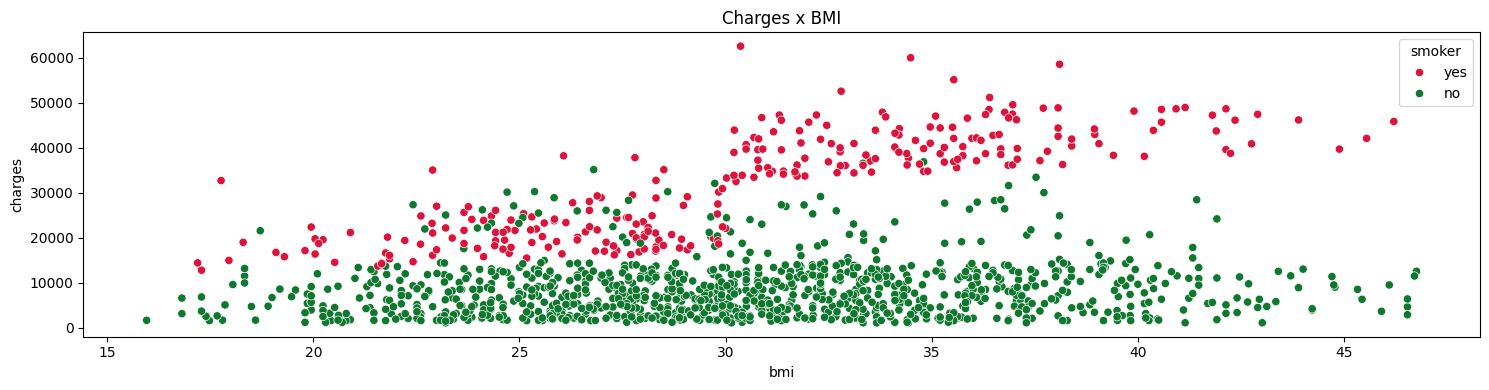

In [26]:
fig = plt.subplots(figsize=(15, 4), sharex=True)

palette = sns.color_palette(["crimson", "#0f782e"])

ax = sns.scatterplot(data=df, y='charges', x="bmi", palette=palette, hue='smoker')
ax.set_title('Charges x BMI')

# Aesthetic
plt.tight_layout()
plt.show()

1. It's visible that're a dense mass of 'red' on the bottom of the image while a less 'blue cloud' is above them. That could be explain by saying that simply are more non-smokers than smokers on data. Or, maybe, there's a hot spot correlationated between the weight of people and the use of cigars that decrease this factor on their bodies. And, we also know at these days, that the nicotine have a loss'weight effect derivative of smoking.

2. After 30 of BMI, if you're a smoker, you charges increase pretty much. In fact, BMI 30 is considered obesity, so we can conclude by that then: For obese people its probably more dangerous to smoke then people with regular BMI.

# Test using Pearson Correlation for 3 factors

It measures the strength and direction of the linear relationship between these two variables, returning a value between -1 and 1:

Near 1: Strong positive relationship (as BMI goes up, medical costs also increase significantly).

Near 0: No linear relationship (weight doesn't seem to affect costs for this group).

Near -1: Strong negative relationship (as BMI goes up, costs decrease).

In [27]:
# Correlation Charges x BMI x Smoking
print(f'Correlation Charges x BMI x Smoking: {df_smokers.charges.corr(df_smokers.bmi)}')

Correlation Charges x BMI x Smoking: 0.8083663783230985


So, as the float returned was 0.8065, close o 1, we can see that the correlation is strongly positive. Upper BMI for smokers, upper is the charge!

## Charges x Age X Smoking

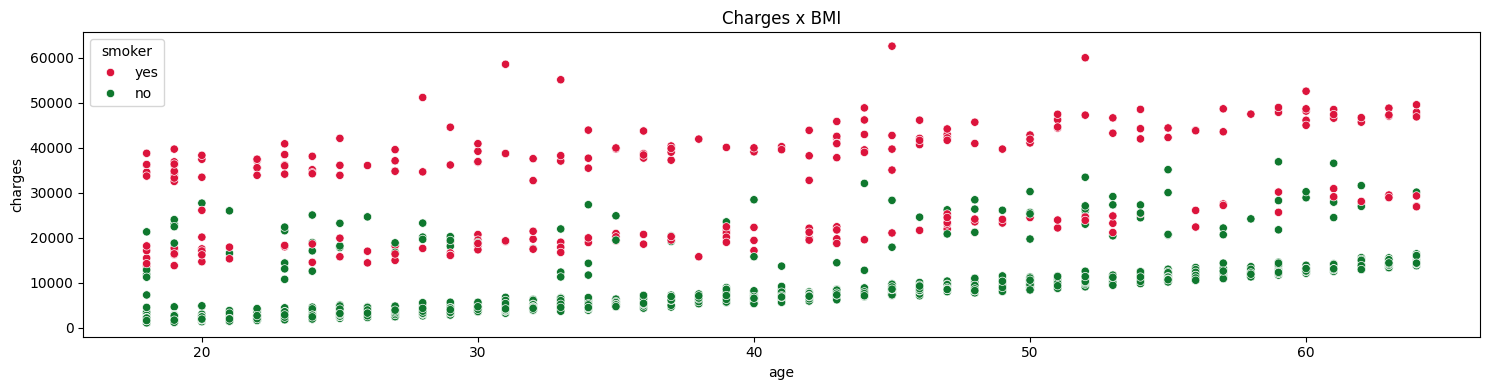

In [28]:
fig = plt.subplots(figsize=(15, 4), sharex=True)

palette = sns.color_palette(["crimson", "#0f782e"])

ax = sns.scatterplot(data=df, y='charges', x="age", palette=palette, hue='smoker')
ax.set_title('Charges x BMI')

# Aesthetic
plt.tight_layout()
plt.show()

If you pay attention, you can see that blue sample looks kinda random arranged by all graph, which mean weak correlation. Red, otherwise, looks different, with most part of samples growing in a linear scale.

## Person Correlation Charges x Age x Smoking

In [29]:
print(f' Pearson correlation for smokers are: {df_smokers.charges.corr(df_smokers.age):.2f} which confirms our suspect')
print(f' Non-smokers person is: {df_non_smokers.charges.corr(df_non_smokers.age):.2f} which is a considerable correlation by the samples')

 Pearson correlation for smokers are: 0.37 which confirms our suspect
 Non-smokers person is: 0.63 which is a considerable correlation by the samples


## We can visualize all we analysed in a heatmap graph

Obs: Only numerics data of smokers

In [30]:
# Separating numeric data

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_smokers_numeric_data = df_smokers.select_dtypes(include=numerics)
df_smokers_numeric_data.head()


,age,bmi,children,charges
0,19,27.90,0,16884.9240
11,62,26.29,0,27808.7251
14,27,42.13,0,39611.7577
19,30,35.30,0,36837.4670
23,34,31.92,1,37701.8768


In [31]:
# Visualizing correlation dat to each column

# Obs: Note that some of them we've aldeary descovered

df_smokers_numeric_data.corr()

,age,bmi,children,charges
age,1.000000,0.068759,0.085638,0.371052
bmi,0.068759,1.000000,-0.010061,0.808366
children,0.085638,-0.010061,1.000000,0.043564
charges,0.371052,0.808366,0.043564,1.000000


<Axes: >

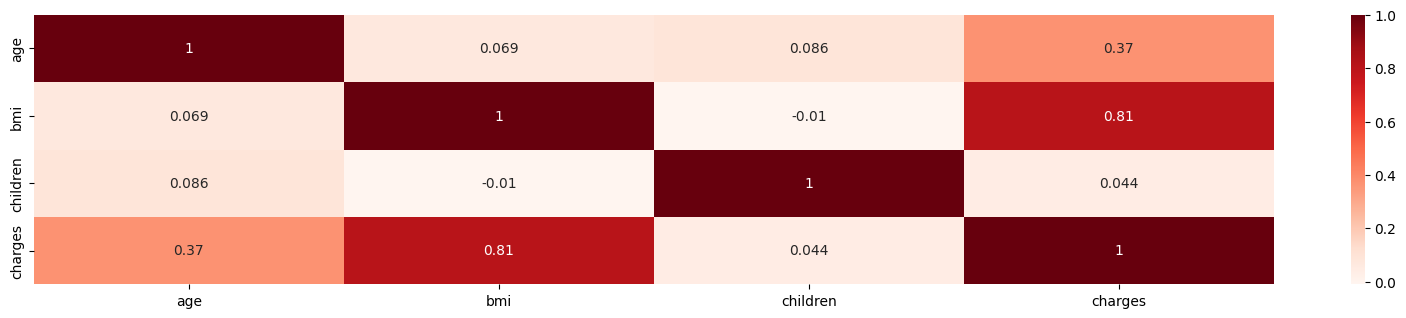

In [32]:
# Ploting

fig4, ax = plt.subplots(figsize=(20, 3.5))

sns.heatmap(data=df_smokers_numeric_data.corr(),
            cmap='Reds',
            annot=True,
            ax=ax)

### As we saw before, smokers have much correlation with high BMI and high Charges. But, what about non-smokers? Shall data be as we saw?

In [33]:
# Separating numeric data

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_non_smokers_numeric_data = df_non_smokers.select_dtypes(include=numerics)
df_non_smokers_numeric_data.corr()


,age,bmi,children,charges
age,1.000000,0.126554,0.033058,0.627088
bmi,0.126554,1.000000,0.024216,0.091750
children,0.033058,0.024216,1.000000,0.138468
charges,0.627088,0.091750,0.138468,1.000000


<Axes: >

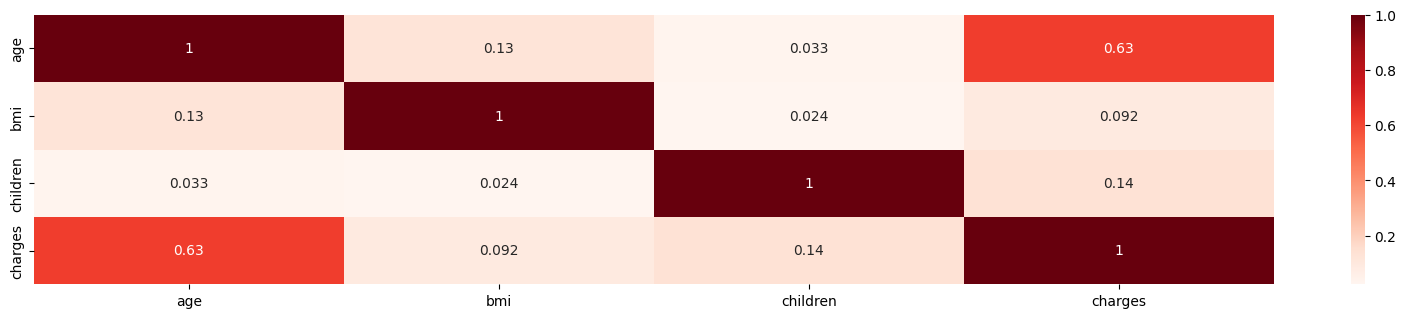

In [34]:
# Ploting

fig4, ax = plt.subplots(figsize=(20, 3.5))

sns.heatmap(data=df_non_smokers_numeric_data.corr(),
            cmap='Reds',
            annot=True,
            ax=ax)

### And, for our (not big) surprise... Yes, it beats with previous data

## Now, lets search other correlations with other graphs

1) Does smoking have a relation with sex?

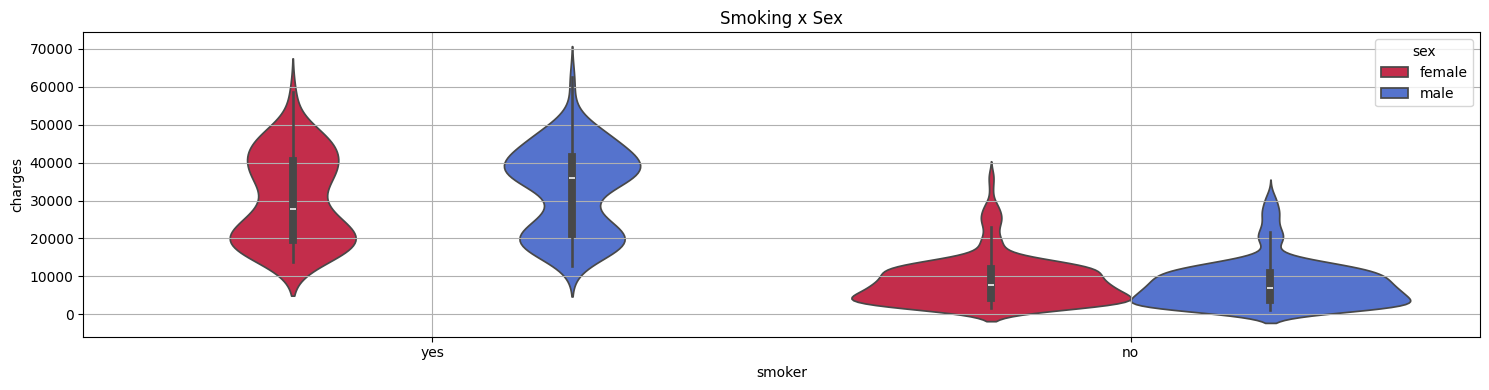

In [35]:
palette = sns.color_palette(["crimson", "royalblue"])

fig = plt.subplots(figsize=(15, 4), sharex=True)

ax = sns.violinplot(data=df, y='charges', x="smoker", palette=palette, hue='sex')
ax.set_title('Smoking x Sex')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

Answer: No, there's no relevant information to make us conclude that smoking affect women diferent of men

## Does medical charging affects people the number of kids they have?

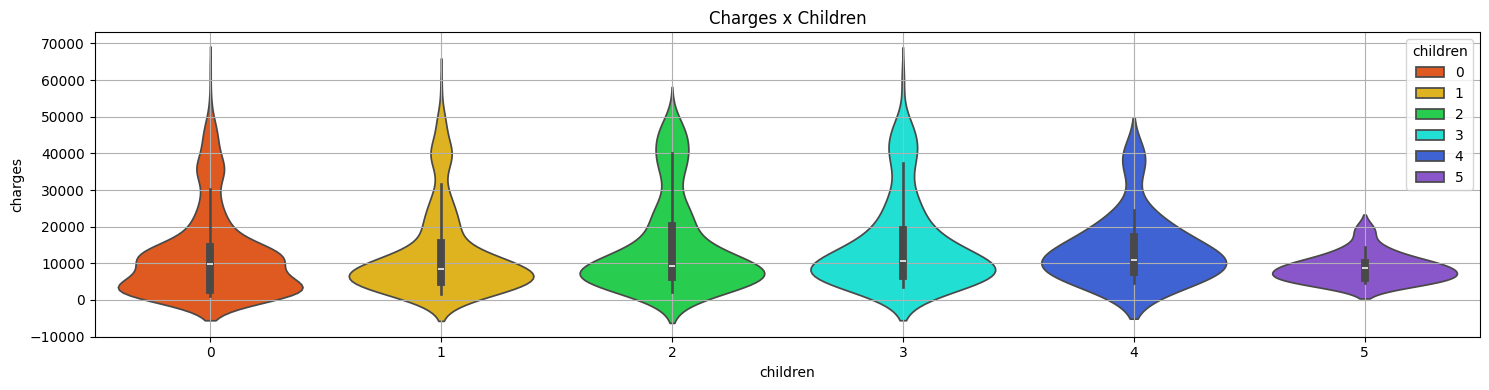

In [36]:
fig = plt.subplots(figsize=(15, 4), sharex=True)

palette = sns.color_palette(["#ff4d01", "#ffc400", "#0ce83f", "#02ffee", "#2657ec", "#8644dc"])

ax = sns.violinplot(data=df, y='charges', x="children", palette=palette, hue='children')
ax.set_title('Charges x Children')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

### In a first look, we can conclude that the more kids you have, less it's gonna be you charges, but it'd be just unbelievably simple

Remember that we already proved that smokers have more charges than non-smokers, so what if we put non-smokers data only, the results are very similar undependent of many children people have

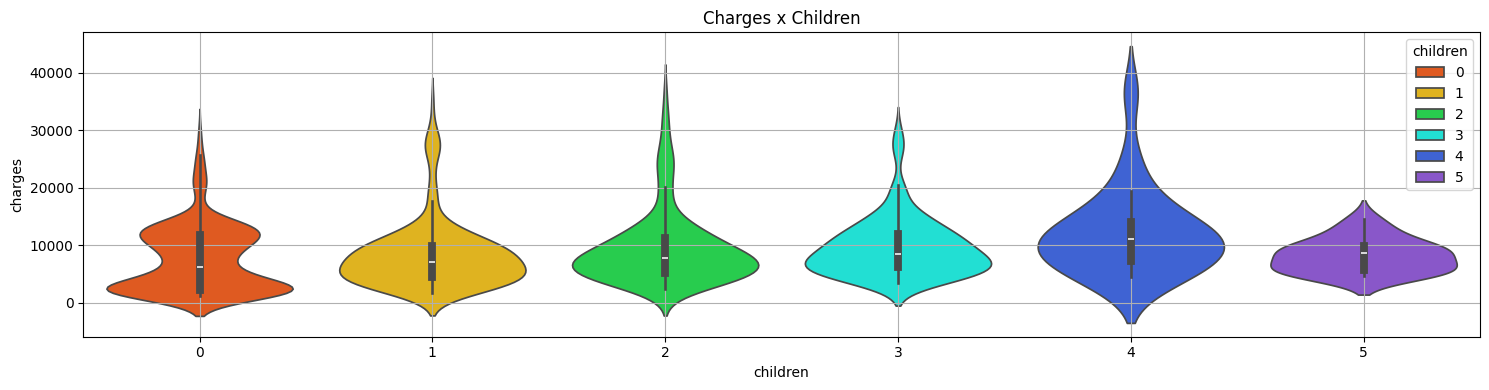

In [37]:
fig = plt.subplots(figsize=(15, 4), sharex=True)

palette = sns.color_palette(["#ff4d01", "#ffc400", "#0ce83f", "#02ffee", "#2657ec", "#8644dc"])

ax = sns.violinplot(data=df_non_smokers, y='charges', x="children", palette=palette, hue='children')
ax.set_title('Charges x Children')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

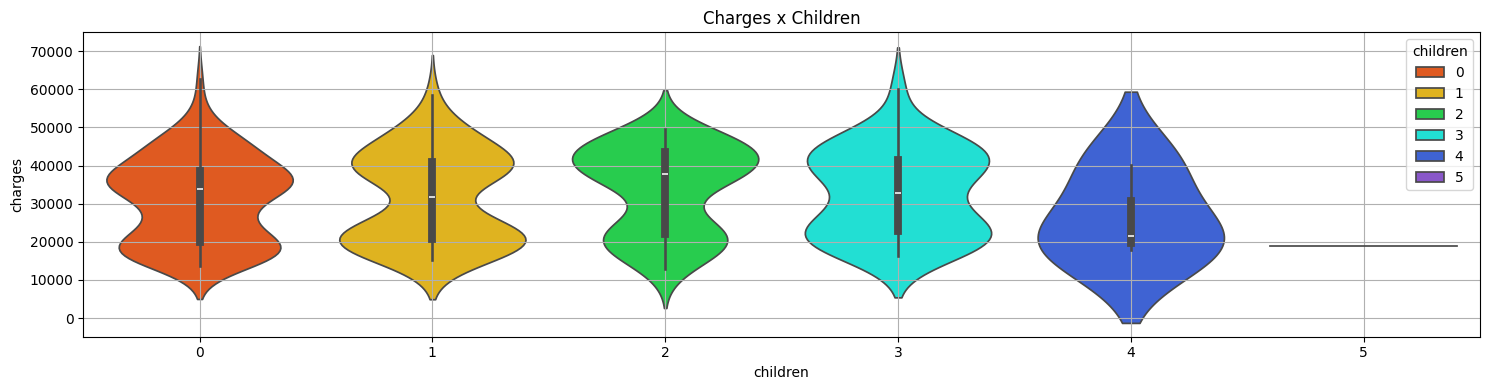

In [38]:
fig = plt.subplots(figsize=(15, 4), sharex=True)

palette = sns.color_palette(["#ff4d01", "#ffc400", "#0ce83f", "#02ffee", "#2657ec", "#8644dc"])

ax = sns.violinplot(data=df_smokers, y='charges', x="children", palette=palette, hue='children')
ax.set_title('Charges x Children')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

### Also, we can point:

1) If you're seriously diseased probably you won't have more kids than someone who's healthy

2) Even if you've many kids, probably you shall pay more bills than someone who's single, so instead of paying medical charges mostly, maybe you'll spend more money with other things (deaper, fixing, toys, computer, cellphones, food)

## There're any difference of smokers charges by region? Let's see

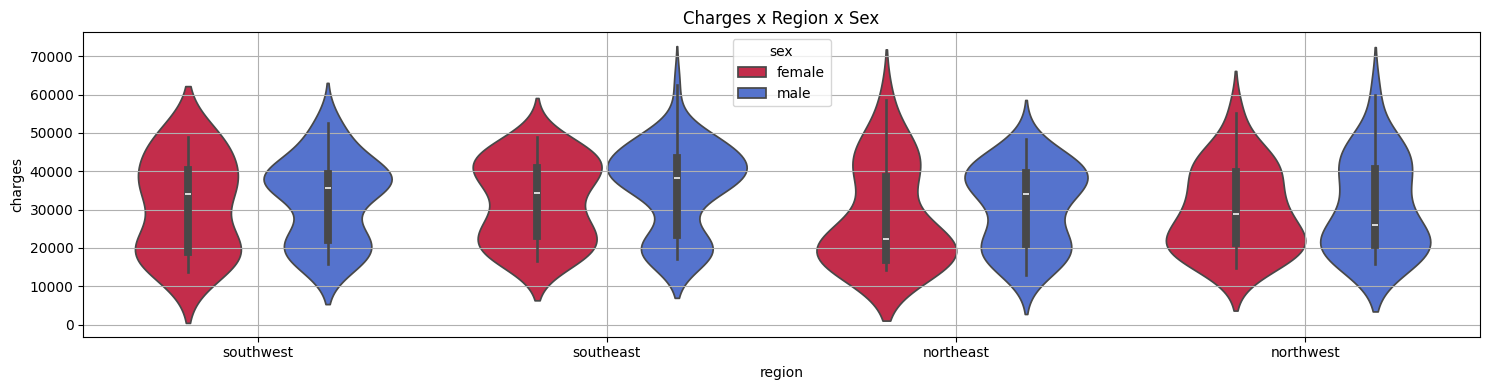

In [39]:
palette = sns.color_palette(["crimson", "royalblue"])

fig = plt.subplots(figsize=(15, 4), sharex=True)

ax = sns.violinplot(data=df_smokers, y='charges', x="region", palette=palette, hue='sex')
ax.set_title('Charges x Region x Sex')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

We see a little more tendence of southesters women paying in round on $40k more than others, nothwesters in round of $50k. Men a little less in northeast.

At all, there're nothing strange or notable in here

### And Non-Smokers?

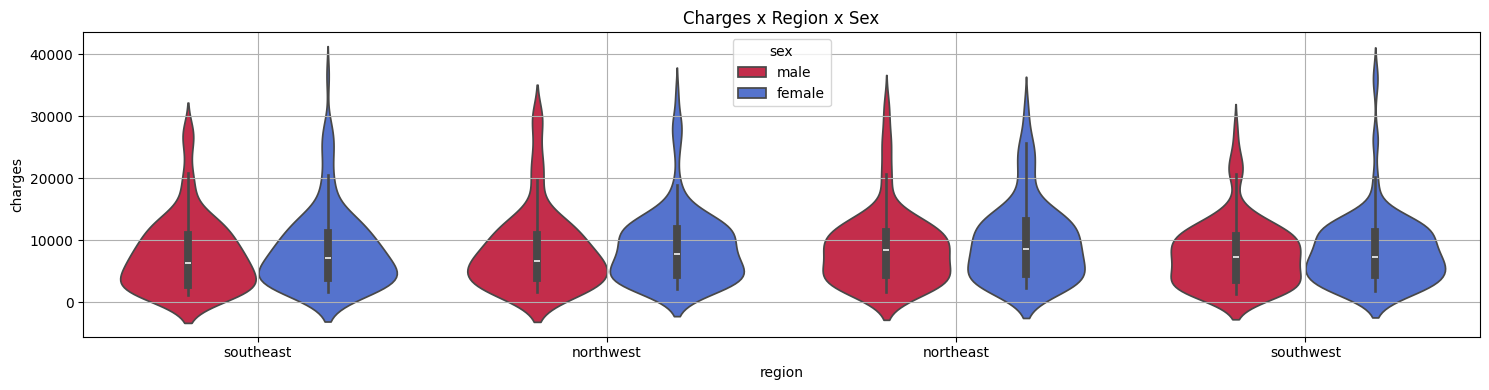

In [40]:
palette = sns.color_palette(["crimson", "royalblue"])

fig = plt.subplots(figsize=(15, 4), sharex=True)

ax = sns.violinplot(data=df_non_smokers, y='charges', x="region", palette=palette, hue='sex')
ax.set_title('Charges x Region x Sex')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

They're very similar, nothing to notice in this data

## Which region has more smokers?

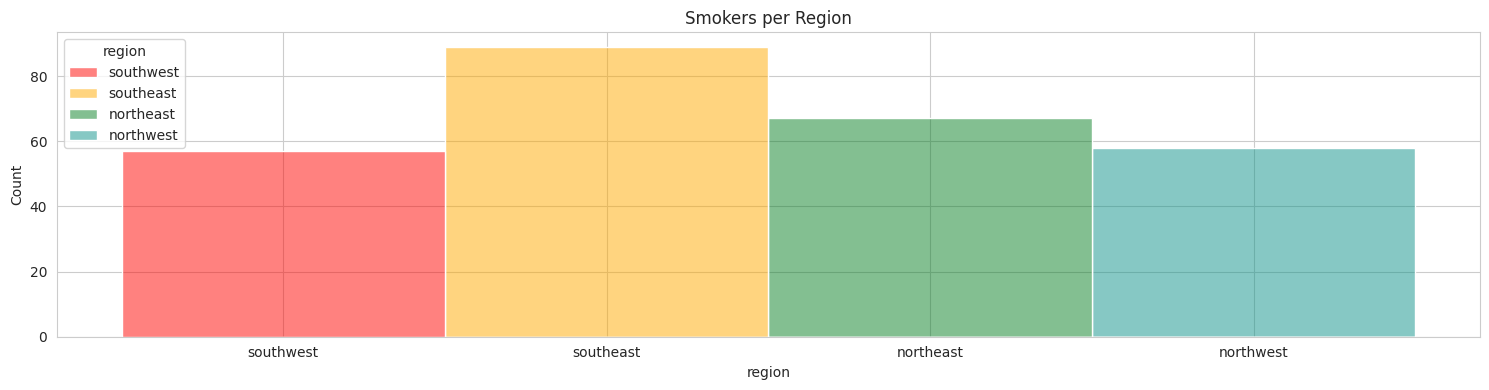

In [53]:
palette = sns.color_palette(["#ff0501", "#ffaa00", "#098025", "#0f938a"])

plt.subplots(figsize=(15, 4), sharex=True)

ax = sns.histplot(data=df_smokers, x="region", palette=palette, hue='region')
ax.set_title('Smokers per Region')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

I wonder what region have more amount of charges...

### In overall, what region spends more money on charges?

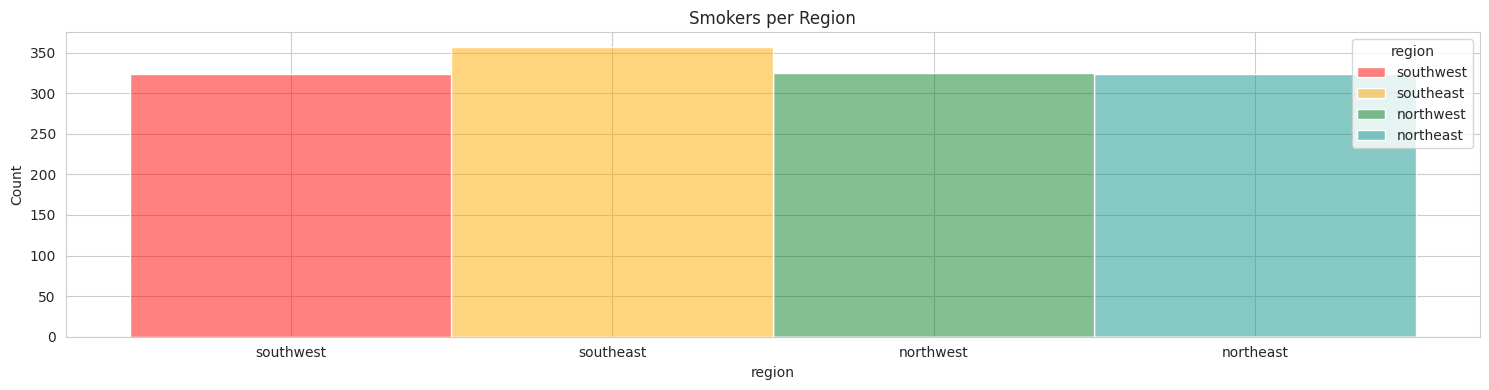

In [54]:
palette = sns.color_palette(["#ff0501", "#ffaa00", "#098025", "#0f938a"])

plt.subplots(figsize=(15, 4), sharex=True)

ax = sns.histplot(data=df, x="region", palette=palette, hue='region')
ax.set_title('Smokers per Region')

# Aesthetic
plt.tight_layout()
plt.grid(True)
plt.show()

Big surprise! (just kidding)

* Notice that nothwest have more smokers than northeast, but less charges. Maybe people in northeast smokes more than them, or coincidently the consequences of smoking
was more several to northeasters in the time of data. It's recomended to take another data in while to compare results

# Supervisioned Learning with TensorFlow and SKlearn
### How to find out which person smokes or not based only on BMI and Charges

##### As we saw before, there's a strong association between smokers and high index of BMI and high medical charges, 81% of occurency to be precise. So, what we just need is to create a linear regression to rate this data and use it to train our machine!

### Importing Library

In [43]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go

### Setting parameters on axis

In [44]:
X_regress = df[['bmi']]
y_regress = df['charges']

# Trainning samples
X_train, X_test, y_train, y_test = train_test_split(X_regress, y_regress, test_size=0.2, random_state= 43)

# Rescaling X-axis parameters on fit
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating our linear regression model
model_regression = SGDRegressor(max_iter=1000, tol=1e-3, random_state=76)
model_regression.fit(X_train_scaled, y_train)

# Predictind f(x)=y function by X_test_scaled
y_pred = model_regression.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

print(f"Coeficient:{model_regression.coef_[0]:.2f}")
print(f"Interceptation: {model_regression.intercept_[0]:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {mse**0.5:.2f}")


Coeficient:2375.40
Interceptation: 13072.68
MSE: 149101525.48
RMSE: 12210.71


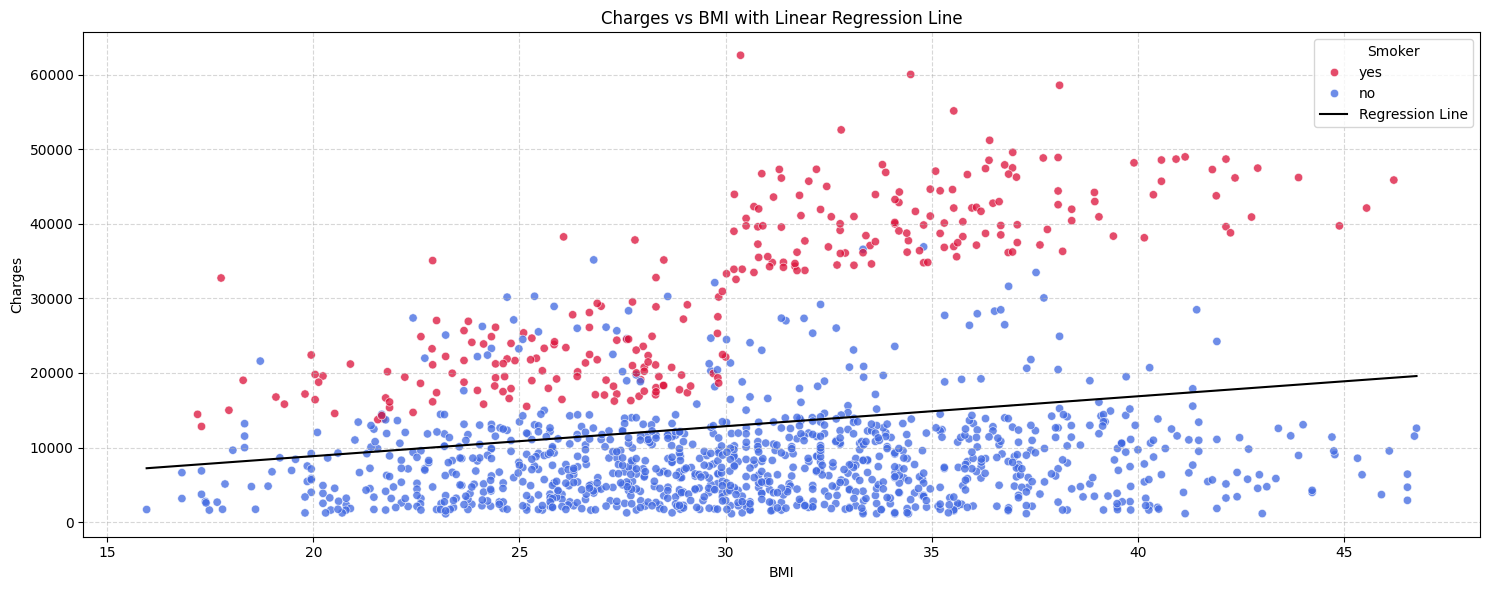

In [45]:
# Reusing scaler com os nomes de colunas corretos para evitar avisos do sklearn
x_scaled = scaler.transform(df[['bmi']]).flatten()

# Calculando a reta: y = b0 + b1 * x
y_pred = model_regression.intercept_[0] + x_scaled * model_regression.coef_[0]

# Configurando a paleta e a figura
palette = {"yes": "crimson", "no": "royalblue"}
plt.figure(figsize=(15, 6))

# 1. Scatterplot para os dados reais
ax = sns.scatterplot(
    data=df, x='bmi', y='charges', hue='smoker',
    palette=palette, alpha=0.76
)

# 2. Plotando a reta de regressão (Manualmente)
# Usamos o bmi original no eixo X e o y_pred calculado
sns.lineplot(x=df['bmi'], y=y_pred, color='black', label='Regression Line', ax=ax)

# Estética
ax.set_title('Charges vs BMI with Linear Regression Line')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges')
plt.legend(title='Smoker')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Obs: yes, we could've fitted this on just smokers, but that'd mistake our porpuse of select smokers randomly

## Importing Library for Learning

In [46]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import layers, Sequential


# 1. Preparing Labels (Grape Varieties)
le = LabelEncoder()
y = le.fit_transform(df['smoker'])
X = df[['bmi', 'charges']].values

# 2. Splitting the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

X_train_scaled_predict = scaler.fit_transform(X_train)
X_test_scaled_predict = scaler.transform(X_test)

model = Sequential([
    layers.Input(shape=(2,)),
    # Entry layer with 2 neurons (bmi and charges)
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    # Output layer with activating Sigmoid (Classifying Smokers by 1 or 0)
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Training
history = model.fit(
    X_train_scaled_predict, y_train, 
    epochs=15, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1,
    validation_data=(
        X_test_scaled_predict, y_test
    )
)

I0000 00:00:1777687070.175677    1842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777687070.180787    1842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777687070.979027    1842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777687073.535042    1842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Epoch 1/15


E0000 00:00:1777687074.052438    1842 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5325 - loss: 0.6850 - val_accuracy: 0.8233 - val_loss: 0.6305
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8589 - loss: 0.5889 - val_accuracy: 0.8947 - val_loss: 0.5437
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8815 - loss: 0.5067 - val_accuracy: 0.8910 - val_loss: 0.4661
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8824 - loss: 0.4321 - val_accuracy: 0.8910 - val_loss: 0.3915
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8881 - loss: 0.3596 - val_accuracy: 0.8947 - val_loss: 0.3204
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8871 - loss: 0.2988 - val_accuracy: 0.8910 - val_loss: 0.2680
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8956 - loss: 0.2546 - val_accuracy: 0.9098 - val_loss: 0.2292
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9040 - loss: 0.2213 - val_accuracy: 0.9173 - val_loss: 0.2010
Epo

In [47]:
# Rating model
print("=" * 60)
print("MODEL EVALUATION: SMOKER CLASSIFIER")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test_scaled_predict, y_test, verbose=0)
print(f"\nLoss on test set: {test_loss:.4f}")
print(f"Accuracy on test set: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions (Probabilities between 0 and 1)
y_pred_probs = model.predict(X_test_scaled_predict, verbose=0)
# Convert probabilities to binary (True if > 0.5)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Some examples to share
print("\n" + "=" * 60)
print("PREDICTION EXAMPLES (BMI & CHARGES)")
print("=" * 60)

import random

for i in random.sample(range(1,X_test_scaled_predict.shape[0]), 10):
    # Mapping back 0/1 to No/Yes
    predicted_status = "Yes" if y_pred[i] == 1 else "No"
    actual_status = "Yes" if y_test[i] == 1 else "No"
    
    # For a sigmoid, confidence is how far it is from the 0.5 threshold
    prob = y_pred_probs[i][0]
    confidence = prob if y_pred[i] == 1 else (1 - prob)
    
    # Accessing original unscaled values (using original X_test index if it's a slice)
    # If X_test_raw is available, use it here:
    bmi_val = X_test_scaled_predict.iloc[i]['bmi'] if 'X_test_raw' in locals() else "N/A"
    charge_val = X_test_scaled_predict.iloc[i]['charges'] if 'X_test_raw' in locals() else "N/A"
    
    print(f"\n--- Person {i+1} ---")
    if bmi_val != "N/A":
        print(f"Features: BMI: {bmi_val:.1f} | Charges: ${charge_val:,.2f}")
    
    print(f"Smoker Predicted: {predicted_status} (Confidence: {confidence*100:.2f}%)")
    print(f"Real Status: {actual_status}")
    print(f"Success: {'✓' if predicted_status == actual_status else '✗'}")

MODEL EVALUATION: SMOKER CLASSIFIER

Loss on test set: 0.1314
Accuracy on test set: 0.9398 (93.98%)

PREDICTION EXAMPLES (BMI & CHARGES)

--- Person 22 ---
Smoker Predicted: No (Confidence: 98.14%)
Real Status: No
Success: ✓

--- Person 122 ---
Smoker Predicted: No (Confidence: 98.44%)
Real Status: No
Success: ✓

--- Person 50 ---
Smoker Predicted: Yes (Confidence: 68.06%)
Real Status: No
Success: ✗

--- Person 125 ---
Smoker Predicted: No (Confidence: 96.78%)
Real Status: No
Success: ✓

--- Person 196 ---
Smoker Predicted: No (Confidence: 97.21%)
Real Status: No
Success: ✓

--- Person 101 ---
Smoker Predicted: No (Confidence: 99.45%)
Real Status: No
Success: ✓

--- Person 69 ---
Smoker Predicted: No (Confidence: 99.67%)
Real Status: No
Success: ✓

--- Person 166 ---
Smoker Predicted: No (Confidence: 99.92%)
Real Status: No
Success: ✓

--- Person 67 ---
Smoker Predicted: No (Confidence: 99.10%)
Real Status: No
Success: ✓

--- Person 218 ---
Smoker Predicted: No (Confidence: 97.00%)
Rea

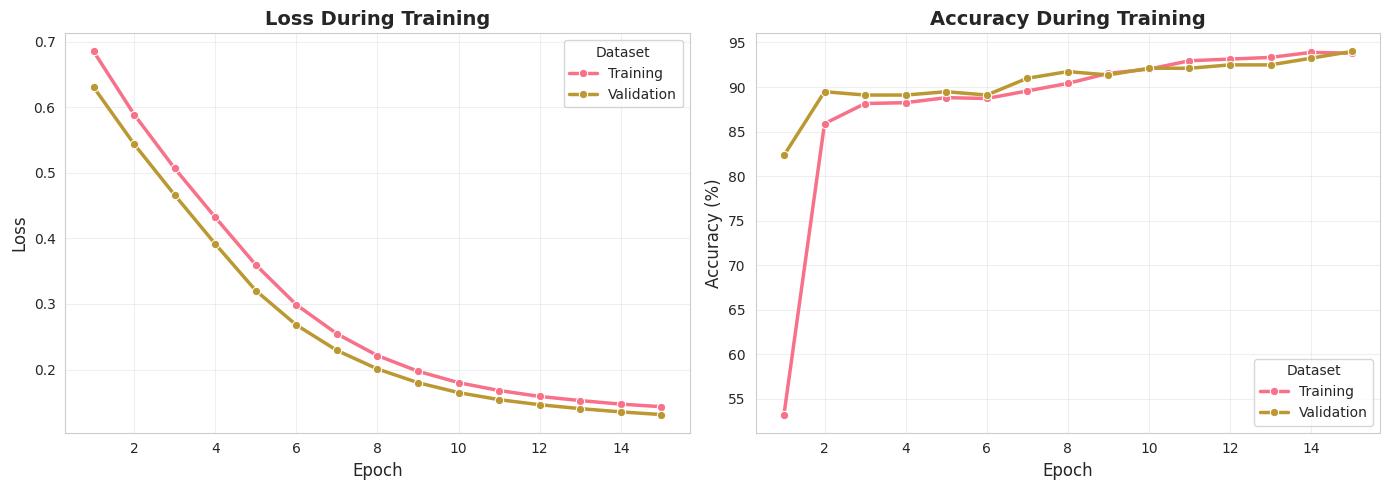


TRAINING SUMMARY

Initial Loss:      0.6850
Final Loss:        0.1434
Reduction:         79.07%

Initial Accuracy:  53.25%
Final Accuracy:    93.79%
Improvement:       40.55%

Val. Accuracy:     93.98%


In [48]:
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert history to DataFrame for Seaborn usage
history_df = pd.DataFrame(history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['loss'],
    'Type': 'Training'
})
val_loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['val_loss'],
    'Type': 'Validation'
})
combined_loss = pd.concat([loss_data, val_loss_data], ignore_index=True)

sns.lineplot(data=combined_loss, x='Epoch', y='Loss', hue='Type', 
             ax=axes[0], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Dataset')

# Plot 2: Accuracy
acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['accuracy'] * 100,
    'Type': 'Training'
})
val_acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['val_accuracy'] * 100,
    'Type': 'Validation'
})
combined_acc = pd.concat([acc_data, val_acc_data], ignore_index=True)

sns.lineplot(data=combined_acc, x='Epoch', y='Accuracy', hue='Type', 
             ax=axes[1], linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Dataset')

plt.tight_layout()
plt.show()

# Metrics Summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"\nInitial Loss:      {history.history['loss'][0]:.4f}")
print(f"Final Loss:        {history.history['loss'][-1]:.4f}")
print(f"Reduction:         {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")

print(f"\nInitial Accuracy:  {history.history['accuracy'][0]*100:.2f}%")
print(f"Final Accuracy:    {history.history['accuracy'][-1]*100:.2f}%")
print(f"Improvement:       {(history.history['accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%")

print(f"\nVal. Accuracy:     {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 80)

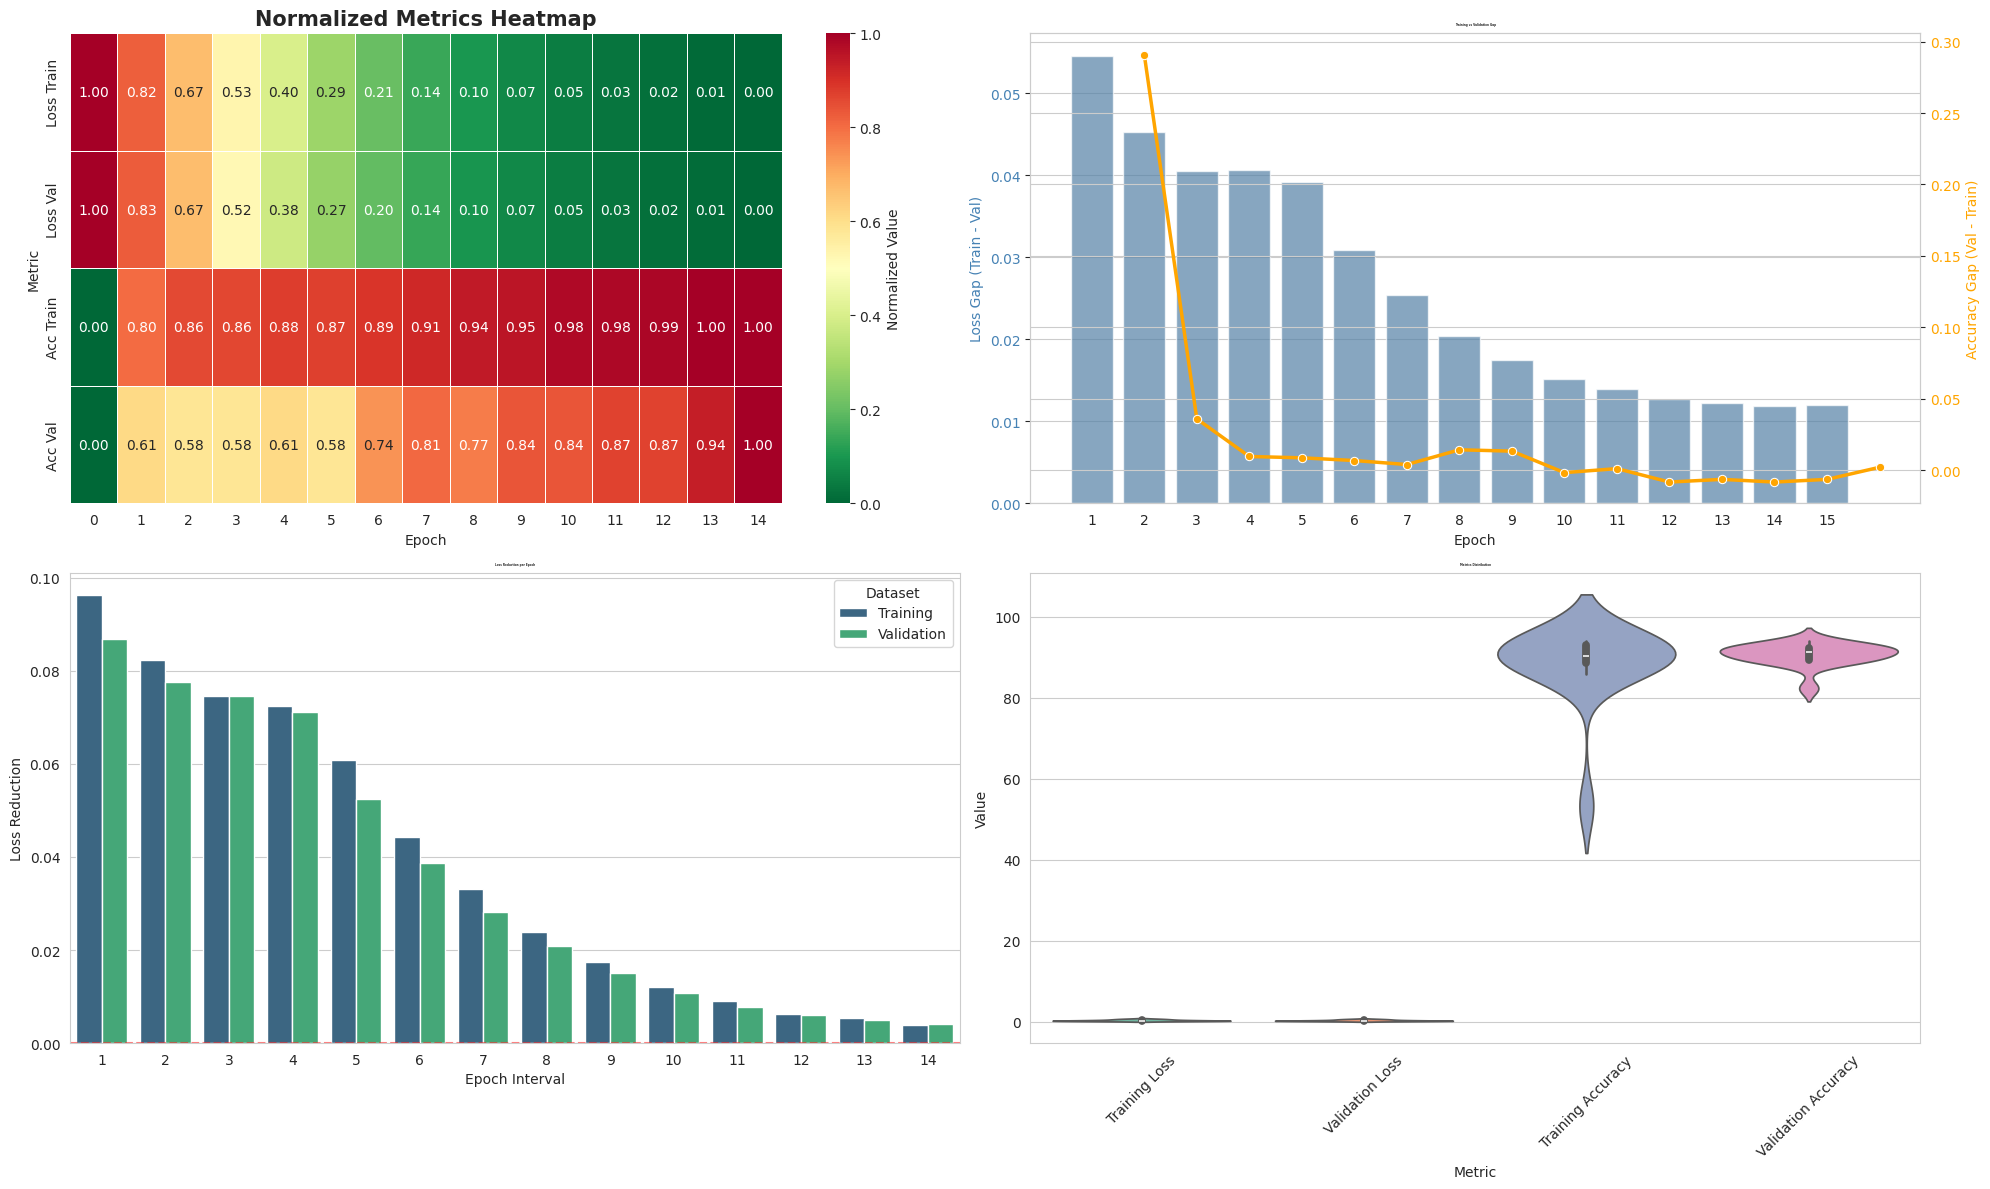


OVERFITTING ANALYSIS

Average Loss Gap (Train - Val): 0.0261
Final Loss Gap: 0.0120

Average Accuracy Gap (Val - Train): 2.36%
Final Accuracy Gap: 0.19%

 Well-balanced model (Low overfitting)


In [49]:
# Create figure with additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Metrics Heatmap
metrics_data = history_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].copy()
metrics_data.columns = ['Loss Train', 'Loss Val', 'Acc Train', 'Acc Val']
# Normalize for better visualization
metrics_normalized = (metrics_data - metrics_data.min()) / (metrics_data.max() - metrics_data.min())

sns.heatmap(metrics_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Normalized Value'}, ax=axes[0, 0], linewidths=0.5)
axes[0, 0].set_title('Normalized Metrics Heatmap', fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Metric')

# Plot 2: Training vs Validation Gap
gap_loss = history_df['loss'] - history_df['val_loss']
gap_acc = history_df['val_accuracy'] - history_df['accuracy']

gap_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss Gap': gap_loss,
    'Acc Gap': gap_acc
})

ax2_twin = axes[0, 1].twinx()
sns.barplot(data=gap_data, x='Epoch', y='Loss Gap', ax=axes[0, 1], color='steelblue', alpha=0.7)
sns.lineplot(data=gap_data, x='Epoch', y='Acc Gap', ax=ax2_twin, color='orange', linewidth=2.5, marker='o')

axes[0, 1].set_title('Training vs Validation Gap', fontsize=2, fontweight='bold')
axes[0, 1].set_ylabel('Loss Gap (Train - Val)', color='steelblue', fontsize=10)
ax2_twin.set_ylabel('Accuracy Gap (Val - Train)', color='orange', fontsize=10)
axes[0, 1].tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='orange')

# Plot 3: Loss Reduction Speed
train_loss_diff = -np.diff(history_df['loss'])
val_loss_diff = -np.diff(history_df['val_loss'])
epochs = list(range(1, len(train_loss_diff) + 1))

# 2. Criamos um DataFrame "long-format" para o Seaborn
diff_data = pd.DataFrame({
    'Epoch_Interval': epochs * 2,
    'Loss_Reduction': np.concatenate([train_loss_diff, val_loss_diff]),
    'Dataset': ['Training'] * len(train_loss_diff) + ['Validation'] * len(val_loss_diff)
})

sns.barplot(
    data=diff_data, 
    x='Epoch_Interval', 
    y='Loss_Reduction', 
    hue='Dataset', 
    ax=axes[1, 0], 
    palette='viridis'
)

axes[1, 0].set_title('Loss Reduction per Epoch', fontsize=2, fontweight='bold')
axes[1, 0].set_xlabel('Epoch Interval')
axes[1, 0].set_ylabel('Loss Reduction')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Plot 4: Metric Distribution
metrics_dist = pd.DataFrame({
    'Training Loss': history_df['loss'],
    'Validation Loss': history_df['val_loss'],
    'Training Accuracy': history_df['accuracy'] * 100,
    'Validation Accuracy': history_df['val_accuracy'] * 100
})

metrics_melted = metrics_dist.reset_index(drop=True).reset_index().melt(
    id_vars='index', 
    var_name='Metric', 
    value_name='Value'
)

sns.violinplot(
    data=metrics_melted, 
    x='Metric', 
    y='Value', 
    hue='Metric', 
    ax=axes[1, 1], 
    palette='Set2', 
    legend=False
)

axes[1, 1].set_title('Metrics Distribution', fontsize=2, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Overfitting Analysis Summary
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)
print(f"\nAverage Loss Gap (Train - Val): {gap_loss.mean():.4f}")
print(f"Final Loss Gap: {gap_loss.iloc[-1]:.4f}")
print(f"\nAverage Accuracy Gap (Val - Train): {gap_acc.mean()*100:.2f}%")
print(f"Final Accuracy Gap: {gap_acc.iloc[-1]*100:.2f}%")

if gap_loss.iloc[-1] < 0.1:
    print("\n Well-balanced model (Low overfitting)")
elif gap_loss.iloc[-1] < 0.3:
    print("\n Slight overfitting detected")
else:
    print("\n Significant overfitting detected")
print("=" * 80)